# Relacion 3 Nanoelectrónica

### Ejercicio 3.1: Realizar el ejercicio 3.9

In [19]:
### LIBRERÍAS #################

from scipy.integrate import quad
import numpy as np
import matplotlib.pyplot as plt

In [20]:
### Constantes universales #######################

hbar = 6.582 *10**(-16)     #eV*s


In [21]:
### Definición de parámetros para el 3.1  ############################3


Ef = -5.0       #eV
Eta = 0.5       
homo = -5.5     #eV
Gamma_s = 0.1   #eV
Gamma_d = 0.1   #eV
T=298           #K
mu_s0 = -5      #eV
mu_d0 = -5      #eV

KT =0.026*T/300 #eV

q_C_es = 1      #eV

Vmax = -4       #eV



In [36]:
### Código para el ejercicio 3.1 #############################################


#Calculamos la función de fermi


def fermi(energia, e_fermi):
    """
    Args:
        energia (Float): Pásale la energía actual del nivel
        e_fermi (Float): Nivel de energía de fermi
    """
    
    resultado = 1/(1+np.exp((energia - e_fermi)/KT))
    return resultado


#print(fermi(Ef, Ef)) (Debe dar un medio)

#Calculamos Tau_s y Tau_D

Tau_s = hbar / Gamma_s
Tau_d = hbar / Gamma_d



#Voy a hacer un bucle barriendo los voltajes.
#Empezaré en un voltaje grande negativo y acabaré en uno grande positivo.
#Para cada voltaje hay que calcularlo todo: N, 

#Calculamos el número de electrones N.
#Como solo hay un nivel y g es una delta multiplico por 2 y me quito la integral.
#No usaremos el nivel de fermi, sino una función escalón


V = np.linspace(-Vmax, Vmax, 201)
N = np.linspace(-Vmax, Vmax, 201)

for i, v in enumerate(V):
    mu_s = mu_s0 + Eta*v
    mu_d = mu_d0 -(1-Eta)*v
    N[i] = 2/(Tau_d+Tau_s)*(Tau_d*np.heaviside(mu_s-homo, 0.5) + Tau_d*np.heaviside(mu_d-homo, 0.5))
    

<function matplotlib.pyplot.show(close=None, block=None)>

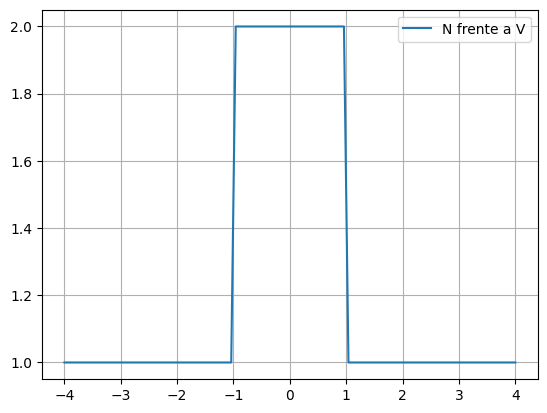

In [37]:
### PLOTEO LOS RESULTADOS ###################

plt.figure()
plt.plot(V, N, label="N frente a V")
plt.grid()
plt.legend()
plt.show